In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/flight_pricing_dataset.csv")
print(df.shape)
print(df.info())
df.head()

(100000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   Flight_ID              100000 non-null  object
 1   Airline                95120 non-null   object
 2   Source                 95085 non-null   object
 3   Destination            95119 non-null   object
 4   Departure_Date         95073 non-null   object
 5   Departure_Time         95132 non-null   object
 6   Arrival_Time           95211 non-null   object
 7   Duration               94958 non-null   object
 8   Total_Stops            95095 non-null   object
 9   Distance_km            95077 non-null   object
 10  Travel_Class           95137 non-null   object
 11  Days_Before_Departure  95216 non-null   object
 12  Season                 95224 non-null   object
 13  Weekday                95280 non-null   object
 14  Aircraft_Type          95148 non-null   

,Flight_ID,Airline,Source,Destination,Departure_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Distance_km,Travel_Class,Days_Before_Departure,Season,Weekday,Aircraft_Type,Booking_Channel,Passenger_Count,Price
0,FL133547,Indigo,Hyderabad,Ahmedabad,2025-08-02,8:10 PM,21:50,1.67,0,910.5,Economy,43,Monsoon,Saturday,Boeing 737,Mobile App,5,5181.56
1,FL133458,AirAsia India,Pune,Mumbai,2025-06-05,12:10,12:55,0h 45m,non-stop,150,Economy,45,Monsoon,Thursday,ATR 72,Website,3,2000
2,FL173851,Qatar Airways,Sydney,PNQ,2025-02-11,5:05 PM,7:53 AM,14.80,1 stop,10168.1,Economy,3,NaN,Tuesday,Boeing 777,Mobile App,3,174762.69
3,FL101953,AirAsia India,Bangalore Airport,BOM,2025-04-19,07:05,10:16 AM,3h 11m,1,868.3,Economy,33,Summer,Saturday,Airbus A320,Mobile App,1,2846.09
4,FL162887,British Airways,Sydney,Goa,2026-07-05,10:40 PM,12:36,13.93,non-stop,10478.0,Economy,6,Monsoon,Sunday,Airbus A320,Website,2,145331.64


In [3]:
def clean_stops(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().lower()
    if val == "non-stop":
        return 0
    match = re.search(r"\d+", val)
    return int(match.group()) if match else np.nan

df["Total_Stops"] = df["Total_Stops"].apply(clean_stops)
df["Total_Stops"].value_counts(dropna=False)

Total_Stops
1.0    44383
0.0    38320
2.0    12392
NaN     4905
Name: count, dtype: int64

In [4]:
def clean_duration(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if "h" in val or "m" in val:
        hours = re.search(r"(\d+)h", val)
        mins = re.search(r"(\d+)m", val)
        h = int(hours.group(1)) if hours else 0
        m = int(mins.group(1)) if mins else 0
        return h * 60 + m
    try:
        return round(float(val) * 60)
    except ValueError:
        return np.nan

df["Duration_Minutes"] = df["Duration"].apply(clean_duration)
df[["Duration", "Duration_Minutes"]].head(10)

,Duration,Duration_Minutes
0,1.67,100.0
1,0h 45m,45.0
2,14.80,888.0
3,3h 11m,191.0
4,13.93,836.0
5,16h 47m,1007.0
6,1h 28m,88.0
7,5h 27m,327.0
8,17h 04m,1024.0
9,3h 20m,200.0


In [5]:
def clean_time(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    for fmt in ("%I:%M %p", "%H:%M"):
        try:
            return pd.to_datetime(val, format=fmt).strftime("%H:%M")
        except ValueError:
            continue
    return np.nan

df["Departure_Time_Clean"] = df["Departure_Time"].apply(clean_time)
df["Arrival_Time_Clean"] = df["Arrival_Time"].apply(clean_time)
df[["Departure_Time", "Departure_Time_Clean", "Arrival_Time", "Arrival_Time_Clean"]].head(10)

,Departure_Time,Departure_Time_Clean,Arrival_Time,Arrival_Time_Clean
0,8:10 PM,20:10,21:50,21:50
1,12:10,12:10,12:55,12:55
2,5:05 PM,17:05,7:53 AM,07:53
3,07:05,07:05,10:16 AM,10:16
4,10:40 PM,22:40,12:36,12:36
5,4:15 AM,04:15,21:02,21:02
6,1:35 AM,01:35,3:02 AM,03:02
7,9:55 AM,09:55,3:21 PM,15:21
8,5:45 AM,05:45,22:49,22:49
9,8:15 AM,08:15,11:35 AM,11:35


In [6]:
numeric_cols = ["Distance_km", "Days_Before_Departure", "Passenger_Count", "Price"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols].describe()

,Distance_km,Days_Before_Departure,Passenger_Count,Price
count,92242.000000,93807.000000,93169.000000,92052.000000
mean,5152.723992,35.841899,2.120319,72973.034449
std,4424.516082,43.798331,1.310547,77661.273028
min,150.000000,0.000000,1.000000,152.130000
25%,1531.400000,7.000000,1.000000,13239.487500
50%,3213.200000,19.000000,2.000000,49103.280000
75%,7901.800000,41.000000,3.000000,113660.277500
max,18353.400000,180.000000,6.000000,999306.030000


In [7]:
code_map = {
    "AMD": "Ahmedabad", "BKK": "Bangkok", "BLR": "Bangalore", "BOM": "Mumbai",
    "CCU": "Kolkata", "DEL": "Delhi", "DOH": "Doha", "DXB": "Dubai",
    "FRA": "Frankfurt", "GOI": "Goa", "HYD": "Hyderabad", "JAI": "Jaipur",
    "JFK": "New York", "LHR": "London", "MAA": "Chennai", "PNQ": "Pune",
    "SIN": "Singapore", "SYD": "Sydney",
}

def clean_city(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val in code_map:
        return code_map[val]
    return val.replace(" Airport", "").strip()

df["Source"] = df["Source"].apply(clean_city)
df["Destination"] = df["Destination"].apply(clean_city)

print("Unique sources:", sorted(df["Source"].dropna().unique()))

Unique sources: ['Ahmedabad', 'Bangalore', 'Bangkok', 'Chennai', 'Delhi', 'Doha', 'Dubai', 'Frankfurt', 'Goa', 'Hyderabad', 'Jaipur', 'Kolkata', 'London', 'Mumbai', 'New York', 'Pune', 'Singapore', 'Sydney']


In [8]:
df["Airline"] = df["Airline"].str.strip().str.upper()
print(sorted(df["Airline"].dropna().unique()))

['AIR INDIA', 'AIRASIA INDIA', 'BRITISH AIRWAYS', 'EMIRATES', 'ETIHAD AIRWAYS', 'GOFIRST', 'INDIGO', 'LUFTHANSA', 'QATAR AIRWAYS', 'SINGAPORE AIRLINES', 'SPICEJET', 'THAI AIRWAYS', 'VISTARA']


In [9]:
df = df.dropna(subset=["Price"])
print("Shape after dropping missing prices:", df.shape)

Shape after dropping missing prices: (92052, 21)


In [10]:
categorical_cols = ["Airline", "Source", "Destination", "Travel_Class",
                     "Season", "Weekday", "Aircraft_Type", "Booking_Channel",
                     "Departure_Date", "Departure_Time", "Arrival_Time",
                     "Duration", "Departure_Time_Clean", "Arrival_Time_Clean"]
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

numeric_fill_cols = ["Distance_km", "Days_Before_Departure", "Passenger_Count",
                      "Total_Stops", "Duration_Minutes"]
for col in numeric_fill_cols:
    df[col] = df[col].fillna(df[col].median())

print("Final shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())

Final shape: (92052, 21)
Total missing values: 0


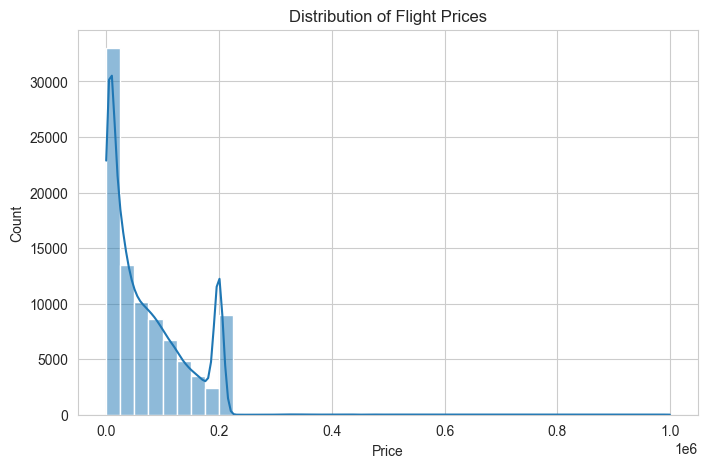

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], kde=True, bins=40)
plt.title("Distribution of Flight Prices")
plt.savefig("../images/price_distribution.png", bbox_inches="tight")
plt.show()

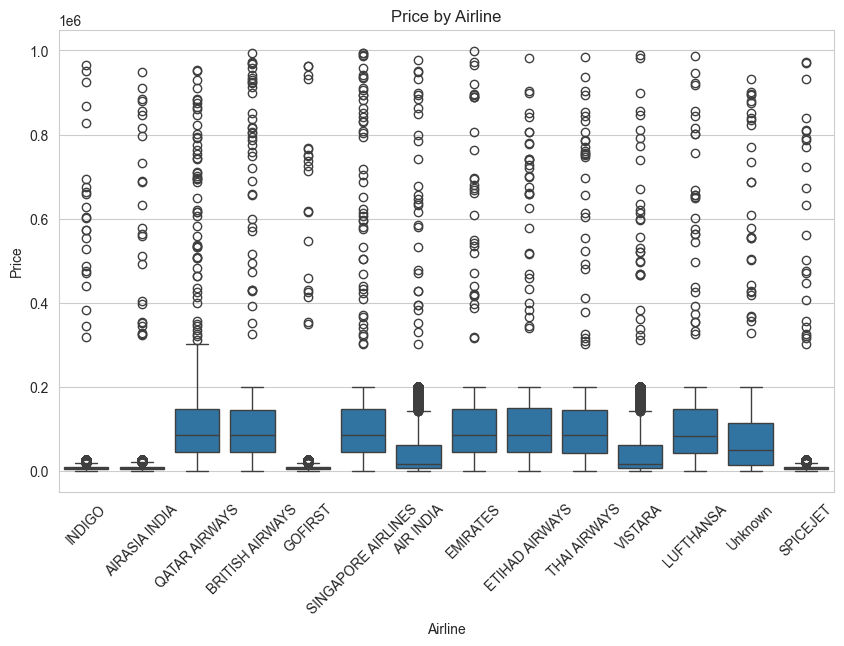

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Airline", y="Price")
plt.xticks(rotation=45)
plt.title("Price by Airline")
plt.savefig("../images/price_by_airline.png", bbox_inches="tight")
plt.show()

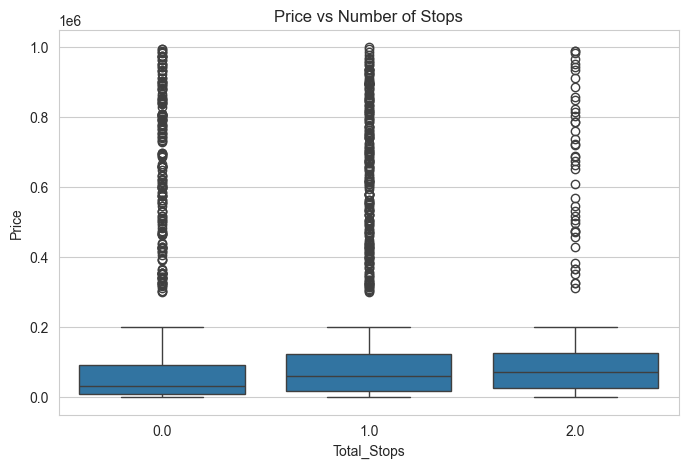

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Total_Stops", y="Price")
plt.title("Price vs Number of Stops")
plt.savefig("../images/price_vs_stops.png", bbox_inches="tight")
plt.show()

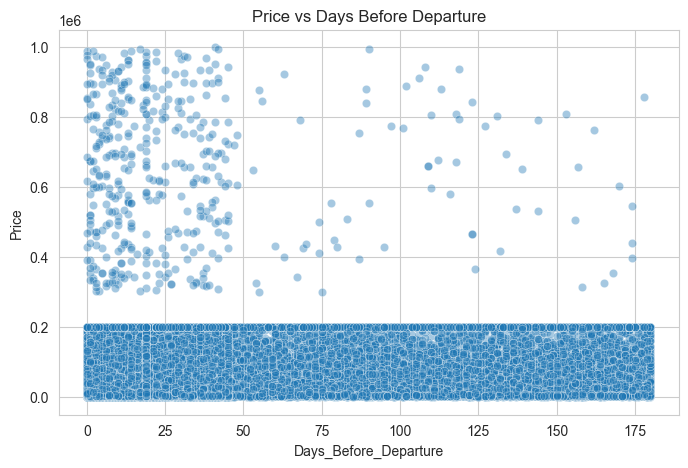

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Days_Before_Departure", y="Price", alpha=0.4)
plt.title("Price vs Days Before Departure")
plt.savefig("../images/price_vs_daysleft.png", bbox_inches="tight")
plt.show()

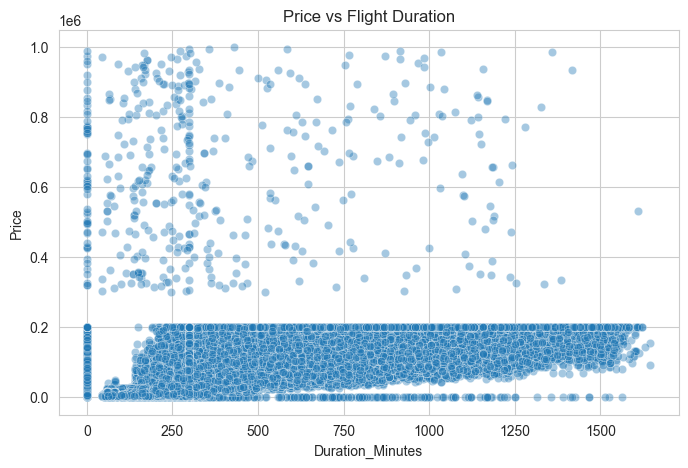

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Duration_Minutes", y="Price", alpha=0.4)
plt.title("Price vs Flight Duration")
plt.savefig("../images/price_vs_duration.png", bbox_inches="tight")
plt.show()

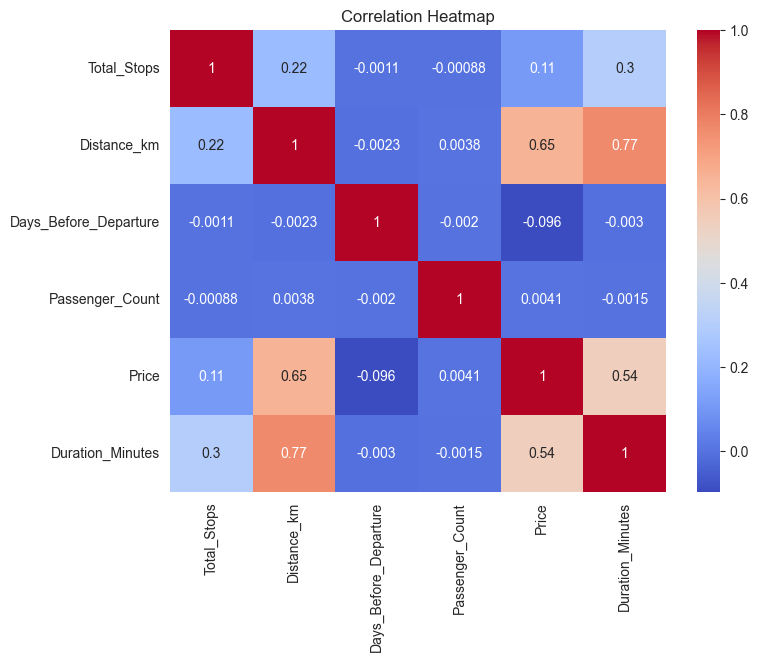

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [17]:
# Average price by number of stops
print("Average price by stops:")
print(df.groupby("Total_Stops")["Price"].mean().round(0))

print("\nAverage price by airline (top 5 most expensive):")
print(df.groupby("Airline")["Price"].mean().sort_values(ascending=False).head(5).round(0))

print("\nAverage price by airline (top 5 cheapest):")
print(df.groupby("Airline")["Price"].mean().sort_values().head(5).round(0))

print("\nCorrelation of each factor with Price:")
print(df.select_dtypes(include=np.number).corr()["Price"].sort_values(ascending=False))

Average price by stops:
Total_Stops
0.0    61578.0
1.0    78883.0
2.0    84656.0
Name: Price, dtype: float64

Average price by airline (top 5 most expensive):
Airline
QATAR AIRWAYS         100967.0
SINGAPORE AIRLINES    100620.0
ETIHAD AIRWAYS        100470.0
BRITISH AIRWAYS        99866.0
EMIRATES               99767.0
Name: Price, dtype: float64

Average price by airline (top 5 cheapest):
Airline
GOFIRST          10350.0
INDIGO           10581.0
AIRASIA INDIA    10808.0
SPICEJET         10849.0
VISTARA          45030.0
Name: Price, dtype: float64

Correlation of each factor with Price:
Price                    1.000000
Distance_km              0.651951
Duration_Minutes         0.543464
Total_Stops              0.112816
Passenger_Count          0.004111
Days_Before_Departure   -0.096355
Name: Price, dtype: float64


## Key Insights

**1. Distance is the single biggest driver of price** (correlation: 0.65)
Flight duration follows closely (correlation: 0.54), which makes sense — longer routes take longer to fly. Together, distance and duration explain most of the price variation in this dataset.

**2. There's a clear budget vs. full-service airline split**
- Budget carriers average ₹10,300–10,900: GoFirst (₹10,350), Indigo (₹10,581), AirAsia India (₹10,808), SpiceJet (₹10,849)
- Full-service international carriers average ~₹99,800–101,000: Qatar Airways (₹100,967), Singapore Airlines (₹100,620), Etihad Airways (₹100,470), British Airways (₹99,866), Emirates (₹99,767)
- This is roughly a **10x price gap** between the cheapest and most expensive airline tiers — almost entirely explained by route type (domestic short-hop vs. international long-haul) rather than airline branding alone.

**3. More stops correlates with higher prices, but weakly** (correlation: 0.11)
Average price rises from ₹61,578 (non-stop) → ₹78,883 (1 stop) → ₹84,656 (2 stops). This is likely a side effect rather than a cause: multi-stop itineraries tend to be the longer international routes, not because stops themselves add cost.

**4. Booking earlier saves a small amount, but the effect is weak** (correlation: -0.096)
Prices don't rise sharply as departure approaches in this dataset — the "book early to save" advice holds, but the effect size is modest compared to route distance.

**5. Passenger count has no relationship with price** (correlation: 0.004)
Group size doesn't meaningfully affect per-ticket price in this dataset.

## Recommendations for Travelers

1. **Route matters more than timing.** Since distance is by far the strongest price driver, the biggest savings come from route/airline choice, not last-minute booking strategy.
2. **Budget carriers offer dramatic savings on comparable domestic routes** — Indigo, GoFirst, and SpiceJet average roughly 10x cheaper than full-service international airlines.
3. **Booking earlier gives a modest edge, so it's worth doing, but don't expect large savings from timing alone** — the correlation is weak.
4. **Don't over-optimize for stops.** Avoiding stops is often about convenience and travel time rather than significant cost savings.